<a href="https://colab.research.google.com/github/gilchristes/24BSE1211-PDE-MicroProject-Group8/blob/main/Group8_PDE_MicroProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1D Image Blurring and Restoration — Phase 2: Computational Micro-Project

**Course:** 24BSE2113-D — Partial Differential Equations, Transforms and Optimization Techniques
**Topic:** Topic 2 — 1D Image Blurring and Restoration (The Heat Equation)
**Group Number:** 8

**Members:**
 1.  Gilchrist E S (32)
 2. Aydin Ziyad Muhammed(18)
 3. Thejus Mary Biju (67)
 4. Gokul V Nair (33)
 5. G Sibiraj (34)

**Course Coordinator:** Siju K S


## 1. Computational Approach

In Phase 1 we solved the 1D heat equation

$$\frac{\partial I(x,t)}{\partial t} = \alpha \frac{\partial^2 I(x,t)}{\partial x^2}, \qquad 0<x<L,\ t>0$$

analytically, for a scan line carrying a sharp step-edge intensity profile

$$I(x,0)=f(x)=\begin{cases}0, & 0\le x<L/2\\ 1, & L/2<x\le L\end{cases}$$

subject to Dirichlet  boundary conditions $I(0,t)=I(L,t)=0$. Separation of variables gave the closed-form Fourier sine series

$$I(x,t)=\sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right)\exp\!\left[-\alpha\left(\frac{n\pi}{L}\right)^2 t\right], \qquad b_n=\frac{2}{n\pi}\left[\cos\!\left(\frac{n\pi}{2}\right)-\cos(n\pi)\right].$$

In this notebook we:

1. **Implement the Fourier series solution directly** (truncated to $N$ terms) using `numpy`, and evaluate/plot $I(x,t)$ at $t=0,\ 0.1,\ 0.5$ —
2. **Visualize the full space–time evolution** of $I(x,t)$


## 2. Setup and Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# --- Physical parameters ---
L = 1.0        # length of the scan line (normalised units)
alpha = 0.01   # diffusion coefficient (controls blurring rate)

# --- Fourier series truncation ---
N_terms = 300  # number of harmonics summed (higher N -> sharper edge at t=0)

# --- Time steps to visualise, as specified in the assignment brief ---
t_values = [0.0, 0.1, 0.5]

print(f"L = {L} m,  alpha = {alpha},  N_terms = {N_terms}")
print(f"Visualising I(x,t) at t = {t_values}")

L = 1.0 m,  alpha = 0.01,  N_terms = 300
Visualising I(x,t) at t = [0.0, 0.1, 0.5]


## 3. Analytical (Fourier Series) Solution

This directly implements the closed-form result derived in Phase 1, Equation (22).
The coefficients $b_n$ vanish for $n\equiv 0\pmod 4$ and take the values $2/(n\pi)$ or $-4/(n\pi)$
otherwise  — a consequence of combining the step-edge initial
condition with clamped (Dirichlet) boundaries.

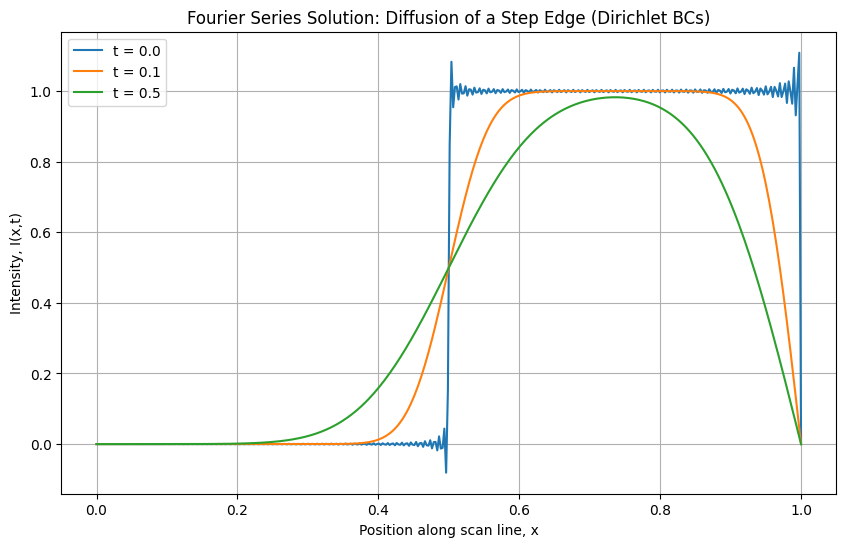

In [2]:
def b_n(n):
    '''Fourier sine coefficients for the step-edge initial condition
    under Dirichlet boundary conditions (Phase 1, Eq. 20-21).'''
    return (2.0 / (n * np.pi)) * (np.cos(n * np.pi / 2) - np.cos(n * np.pi))


def I_fourier(x, t, N=N_terms, L=L, alpha=alpha):
    '''Evaluate the truncated Fourier sine series solution I(x,t)
    (Phase 1, Eq. 22) at spatial points x and time t.'''
    x = np.atleast_1d(x).astype(float)
    n = np.arange(1, N + 1).reshape(-1, 1)      # column vector of harmonics
    bn = b_n(n)
    terms = bn * np.sin(n * np.pi * x / L) * np.exp(-alpha * (n * np.pi / L) ** 2 * t)
    return np.sum(terms, axis=0)                # sum over all harmonics


# Spatial grid for plotting
x_plot = np.linspace(0, L, 400)

plt.figure(figsize=(10, 6))
for t in t_values:
    plt.plot(x_plot, I_fourier(x_plot, t), label=f"t = {t}")

plt.xlabel("Position along scan line, x")
plt.ylabel("Intensity, I(x,t)")
plt.title("Fourier Series Solution: Diffusion of a Step Edge (Dirichlet BCs)")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** at $t=0$ the truncated series reproduces the sharp step edge, with
small oscillations near the jump ($x=L/2$) — this is the **Gibbs phenomenon**, an
unavoidable artefact of approximating a discontinuity with a finite number of smooth
sine terms. As $t$ increases to $0.1$ and then $0.5$, the profile visibly rounds off and
both ends are pulled toward $I=0$, consistent with the clamped boundary conditions.

## 4. 3D Visualisation

 we visualise $I(x,t)$ as a continuous surface over both space and time, using the
analytical Fourier series solution, to see the full diffusion process rather than just
three snapshots.

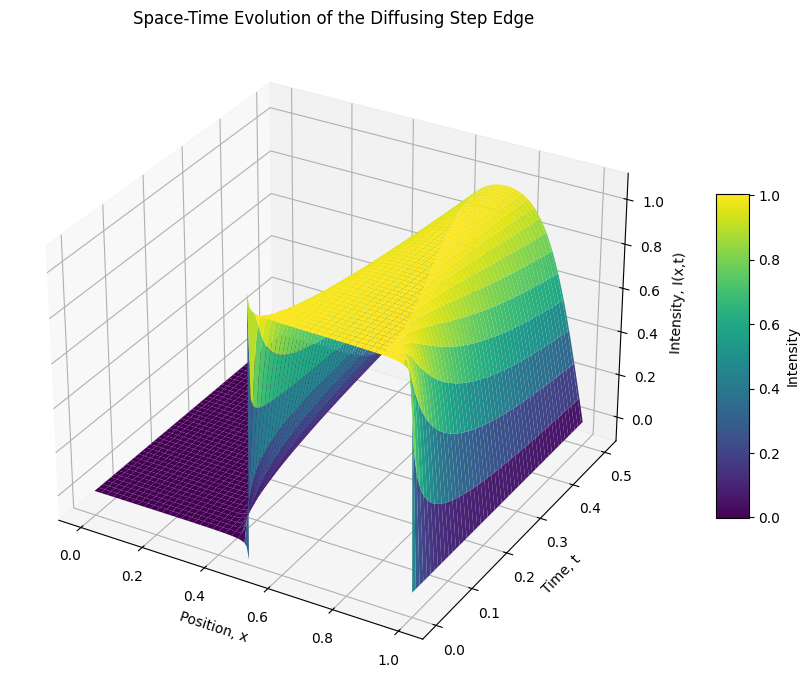

In [3]:
x_surface = np.linspace(0, L, 150)
t_surface = np.linspace(0, 0.5, 100)
X, Tg = np.meshgrid(x_surface, t_surface)

# Evaluate I(x,t) over the full grid
Z = np.array([I_fourier(x_surface, t) for t in t_surface])

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Tg, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel("Position, x")
ax.set_ylabel("Time, t")
ax.set_zlabel("Intensity, I(x,t)")
ax.set_title("Space-Time Evolution of the Diffusing Step Edge")
fig.colorbar(surf, shrink=0.5, aspect=10, label="Intensity")
plt.tight_layout()
plt.show()

## 5. Physical Interpretation and Engineering Conclusions

- **Blurring as low-pass filtering.** The 3D surface makes the low-pass behaviour visible
  directly: the sharp vertical wall at $x=L/2,\ t=0$ (representing high-frequency detail)
  collapses rapidly, while the broad, smooth shape of the profile persists much longer.
  This is the numerical confirmation of the analytical decay proof from Phase 1
  (Section 4.1): each Fourier mode decays at a rate proportional to $n^2$, so
  high-frequency modes vanish first.

- **Effect of Dirichlet boundaries.** Unlike an insulated system, where the mean
  brightness of the scan line would be conserved, here every mode decays and the entire
  profile drains toward zero as $t\to\infty$ — visible clearly in both the 2D snapshots
  and the 3D surface. This matches the physical picture of an edge diffusing into a
  surrounding region that is held at a fixed dark level.

- **Practical relevance to imaging.** The rate of blurring is controlled entirely by
  $\alpha$ and the elapsed diffusion time $t$ — larger values of either erase detail
  faster, exactly analogous to increasing the standard deviation of a Gaussian blur
  kernel in image processing. This is directly relevant to medical imaging: isotropic
  diffusion filters can suppress high-frequency sensor noise effectively, but because
  genuine anatomical edges (e.g. tissue boundaries) are also high-frequency features,
  the same mechanism blurs them too — motivating edge-preserving alternatives such as
  anisotropic diffusion in practical image restoration pipelines.

